# Retail Sales Analysis Project

## Objective
The goal of this project is to analyze retail transaction data to uncover insights about revenue performance, customer behavior, product trends, and store efficiency.

This analysis focuses on:
- Revenue trends over time
- Top-performing products and categories
- Store performance
- Customer and geographic insights
- Impact of discounts and payment methods

## Data Overview

The dataset consists of multiple tables:
- Transactions: sales records
- Customers: customer information
- Products: product details
- Stores: store locations
- Employees: staff information
- Discounts: discount rules

These datasets were merged into a single analytical dataset for easier analysis.

In [394]:
import pandas as pd
import matplotlib.pyplot as plt

In [395]:
customers = pd.read_csv("customers.csv", low_memory=False)
discounts = pd.read_csv("discounts.csv")
employees = pd.read_csv("employees.csv")
products = pd.read_csv("products.csv")
stores = pd.read_csv("stores.csv", encoding="utf-8")
transactions = pd.read_csv("transactions.csv")

## Data Cleaning

Steps performed:
- Converted date columns to datetime format
- Handled missing values (e.g., size and color filled as "Unknown")
- Resolved encoding issues (special characters, multilingual text)
- Renamed columns for clarity after joins
- Ensured consistent data types across columns

In [397]:
transactions.isnull().sum()

Invoice ID                0
Line                      0
Customer ID               0
Product ID                0
Size                 413102
Color               4350783
Unit Price                0
Quantity                  0
Date                      0
Discount                  0
Line Total                0
Store ID                  0
Employee ID               0
Currency                  0
Currency Symbol           0
SKU                       0
Transaction Type          0
Payment Method            0
Invoice Total             0
dtype: int64

In [398]:
transactions["Date"] = pd.to_datetime(transactions["Date"])

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6416827 entries, 0 to 6416826
Data columns (total 19 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Invoice ID        object        
 1   Line              int64         
 2   Customer ID       int64         
 3   Product ID        int64         
 4   Size              object        
 5   Color             object        
 6   Unit Price        float64       
 7   Quantity          int64         
 8   Date              datetime64[ns]
 9   Discount          float64       
 10  Line Total        float64       
 11  Store ID          int64         
 12  Employee ID       int64         
 13  Currency          object        
 14  Currency Symbol   object        
 15  SKU               object        
 16  Transaction Type  object        
 17  Payment Method    object        
 18  Invoice Total     float64       
dtypes: datetime64[ns](1), float64(4), int64(6), object(8)
memory usage: 930.2+ MB


In [399]:
transactions.columns

Index(['Invoice ID', 'Line', 'Customer ID', 'Product ID', 'Size', 'Color',
       'Unit Price', 'Quantity', 'Date', 'Discount', 'Line Total', 'Store ID',
       'Employee ID', 'Currency', 'Currency Symbol', 'SKU', 'Transaction Type',
       'Payment Method', 'Invoice Total'],
      dtype='object')

In [400]:
discounts = discounts.rename(columns={"Discont": "discount_value"})

discounts["Start"] = pd.to_datetime(discounts["Start"])
discounts["End"] = pd.to_datetime(discounts["End"])

In [401]:
report_df = transactions.merge(customers, on="Customer ID", how="left")

In [402]:
report_df = report_df.merge(products, on="Product ID", how="left")
report_df = report_df.merge(stores, on="Store ID", how="left")
report_df = report_df.merge(employees, on="Employee ID", how="left")

In [403]:
report_df.columns

Index(['Invoice ID', 'Line', 'Customer ID', 'Product ID', 'Size', 'Color_x',
       'Unit Price', 'Quantity', 'Date', 'Discount', 'Line Total',
       'Store ID_x', 'Employee ID', 'Currency', 'Currency Symbol', 'SKU',
       'Transaction Type', 'Payment Method', 'Invoice Total', 'Name_x',
       'Email', 'Telephone', 'City_x', 'Country_x', 'Gender', 'Date Of Birth',
       'Job Title', 'Category', 'Sub Category', 'Description PT',
       'Description DE', 'Description FR', 'Description ES', 'Description EN',
       'Description ZH', 'Color_y', 'Sizes', 'Production Cost', 'Country_y',
       'City_y', 'Store Name', 'Number of Employees', 'ZIP Code', 'Latitude',
       'Longitude', 'Store ID_y', 'Name_y', 'Position'],
      dtype='object')

In [404]:
report_df = report_df.rename(columns={
    "Color_y": "Product Color",
    "Sizes": "Product Size",
    "Color_x": "Transaction Color",
    "Description EN": "Product Description",

    "Store ID_x": "Store ID",
    "Store ID_y": "Store ID Duplicate",

    "City_x": "Customer City",
    "Country_x": "Customer Country",

    "City_y": "Store City",
    "Country_y": "Store Country",

    "Name_x": "Customer Name",
    "Name_y": "Employee Name"
})

In [405]:
report_df["Product Size"] = report_df["Product Size"].fillna("Unknown")
report_df["Product Color"] = report_df["Product Color"].fillna("Unknown")

In [406]:
clean_df = report_df[[
    "Invoice ID",
    "Date",
    "Customer ID",
    "Customer Name",
    "Customer City",
    "Customer Country",

    "Product ID",
    "Category",
    "Sub Category",
    "Product Description",
    "Product Color",
    "Product Size",

    "Store ID",
    "Store Name",
    "Store City",
    "Store Country",

    "Employee ID",
    "Employee Name",

    "Quantity",
    "Unit Price",
    "Line Total",
    "Discount",
    "Invoice Total",
    "Payment Method"
]].copy()

In [407]:
clean_df.head()

,Invoice ID,Date,Customer ID,Customer Name,Customer City,Customer Country,Product ID,Category,Sub Category,Product Description,...,Store City,Store Country,Employee ID,Employee Name,Quantity,Unit Price,Line Total,Discount,Invoice Total,Payment Method
0,INV-US-001-03558761,2023-01-01 15:42:00,47162,Rachel Herman,New York,United States,485,Masculine,Suits and Blazers,Men'S Rustic Fabric Blazer With Texture,...,New York,United States,7,Melissa Wilson,1,80.5,80.5,0.0,126.7,Cash
1,INV-US-001-03558761,2023-01-01 15:42:00,47162,Rachel Herman,New York,United States,2779,Children,Coats,Streetwear Golden Silk,...,New York,United States,7,Melissa Wilson,1,31.5,18.9,0.4,126.7,Cash
2,INV-US-001-03558761,2023-01-01 15:42:00,47162,Rachel Herman,New York,United States,64,Masculine,Coats and Blazers,Luxurious Neutral Suede With Hood,...,New York,United States,7,Melissa Wilson,1,45.5,27.3,0.4,126.7,Cash
3,INV-US-001-03558762,2023-01-01 20:04:00,10142,Debra Acosta DVM,New York,United States,131,Feminine,Coats and Blazers,Formal Blue Jeans With Ruffles,...,New York,United States,6,Jeffery Carlson,1,70.0,42.0,0.4,77.0,Cash
4,INV-US-001-03558762,2023-01-01 20:04:00,10142,Debra Acosta DVM,New York,United States,716,Masculine,T-shirts and Polos,High-Tech Suede White Embroidered,...,New York,United States,6,Jeffery Carlson,1,26.0,26.0,0.0,77.0,Cash


## Feature Engineering

New metrics were created to support analysis:

- Gross Sales = Quantity × Unit Price  
- Discount Rate = Discount (filled missing with 0)  
- Discount Amount = Gross Sales × Discount Rate  
- Net Sales = Gross Sales − Discount Amount  

These metrics allow better understanding of revenue and discount impact.

In [409]:
clean_df["Gross Sales"] = clean_df["Quantity"] * clean_df["Unit Price"]

clean_df["Discount Rate"] = clean_df["Discount"].fillna(0)

clean_df["Discount Amount"] = clean_df["Gross Sales"] * clean_df["Discount Rate"]

clean_df["Net Sales"] = clean_df["Gross Sales"] - clean_df["Discount Amount"]

## Key Business Metrics

- Total Revenue: 825,496,596  
- Total Transactions: 4,540,404  
- Total Units Sold: 7,060,071  
- Average Order Value: ~181.8  
- Total Discount Given: 109,806,034  

### Insight
The business generates high revenue with a large transaction volume, but discounts represent a significant cost (~13% of revenue).

In [411]:
total_revenue = clean_df["Net Sales"].sum()
total_transactions = clean_df["Invoice ID"].nunique()
total_units = clean_df["Quantity"].sum()
avg_order_value = total_revenue / total_transactions
total_discount = clean_df["Discount Amount"].sum()

print("Total Revenue:", total_revenue)
print("Total Transactions:", total_transactions)
print("Total Units Sold:", total_units)
print("Average Order Value:", avg_order_value)
print("Total Discount Given:", total_discount)

Total Revenue: 825496596.2549999
Total Transactions: 4540404
Total Units Sold: 7060071
Average Order Value: 181.81126530921034
Total Discount Given: 109806034.99499995


## Monthly Revenue Trend

### Insight
Revenue shows strong fluctuations with clear spikes toward the end of each year (November–December).

### Business Interpretation
- Sales are highly seasonal
- Likely driven by holiday demand

### Recommendation
Increase inventory, staffing, and marketing efforts before peak months to maximize revenue.

In [413]:
clean_df["Date"] = pd.to_datetime(clean_df["Date"])

clean_df["Month Order"] = clean_df["Date"].dt.to_period("M")
clean_df["Year-Month"] = clean_df["Date"].dt.strftime("%Y-%b")

monthly_sales = (
    clean_df.groupby(["Month Order", "Year-Month"])["Net Sales"]
    .sum()
    .reset_index()
    .sort_values("Month Order")
)

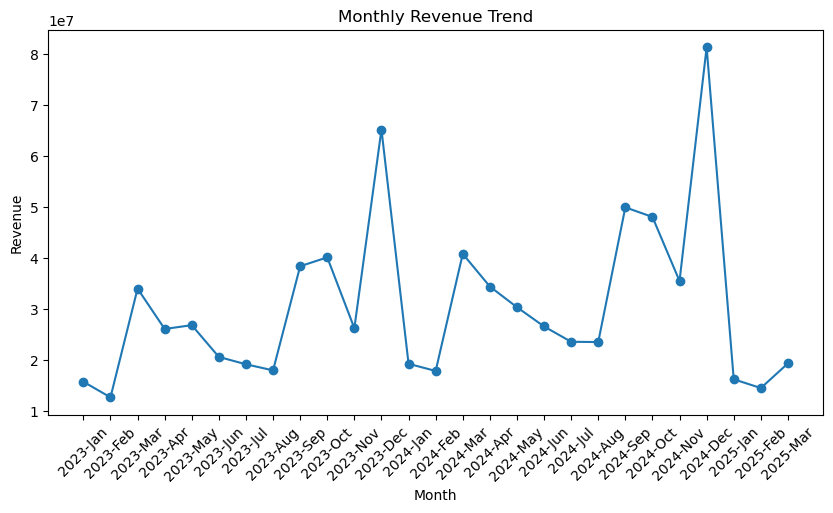

In [414]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Year-Month"], monthly_sales["Net Sales"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Top Products

### Insight
Top-selling products are concentrated in a few categories, especially:
- Suits and Sets
- Pants and Jeans
- Suits and Blazers

### Business Interpretation
A small number of products drive a large portion of revenue.

### Recommendation
- Focus on expanding best-selling categories
- Optimize pricing and inventory for these products

In [416]:
top_products = (
    clean_df.groupby(["Sub Category", "Product Description"])["Net Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [417]:
print(top_products)

        Sub Category                                Product Description  \
0     Suits and Sets                 Tricot Blouse Set And Velvet Skirt   
1     Suits and Sets                   Silk Blouse And Godê Style Skirt   
2    Pants and Jeans           Men'S Twill Pants With Elastic Waistband   
3    Pants and Jeans                        Military Jogger Men'S Pants   
4     Suits and Sets        Gypsy Style Blouse And Midi Skirt With Belt   
5  Suits and Blazers  Men'S Blazer With Clean Style And Contemporary...   
6     Suits and Sets          Cotton Blouse Set With Fake Leather Skirt   
7     Suits and Sets               Crochet Blouse With Linen Midi Skirt   
8  Suits and Blazers               Casual Male Fact With Pocket Details   
9  Suits and Blazers          Male Fact With Premium Merino Wool Fabric   

     Net Sales  
0  1374082.900  
1   945016.200  
2   797535.675  
3   704809.275  
4   682227.150  
5   680181.700  
6   678785.900  
7   669807.800  
8   664504.250  
9   

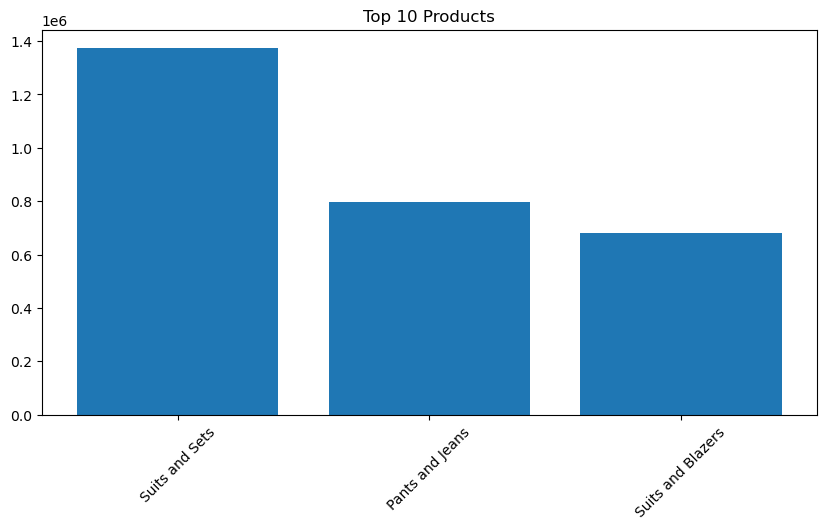

In [418]:
plt.figure(figsize=(10,5))
plt.bar(top_products["Sub Category"], top_products["Net Sales"])
plt.xticks(rotation=45)
plt.title("Top 10 Products")
plt.show()

## Top Store Performance

### Insight
Stores in Asian markets (Shanghai, Guangzhou, Shenzhen, Beijing) significantly outperform others.

### Business Interpretation
- Strong demand in Asian regions
- These markets are key revenue drivers

### Recommendation
- Expand operations in high-performing regions
- Investigate why these stores outperform others (pricing, demand, product mix)

In [420]:
store_name_map = {
    "Store 上海": "Store Shanghai",
    "Store 广州": "Store Guangzhou",
    "Store 深圳": "Store Shenzhen",
    "Store 北京": "Store Beijing",
    "Store 重庆": "Store Chongqing"
}

clean_df["Store Name English"] = clean_df["Store Name"].replace(store_name_map)

In [421]:
store_perf = (
    clean_df.groupby(["Store ID", "Store Name English"])["Net Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(store_perf)

   Store ID Store Name English     Net Sales
0         6     Store Shanghai  1.486485e+08
1         8    Store Guangzhou  1.453482e+08
2         9     Store Shenzhen  1.222847e+08
3         7      Store Beijing  1.123056e+08
4        10    Store Chongqing  7.795043e+07
5         1     Store New York  2.390655e+07
6         2  Store Los Angeles  2.280921e+07
7         4      Store Houston  1.565378e+07
8        11       Store Berlin  1.229250e+07
9         3      Store Chicago  1.196296e+07


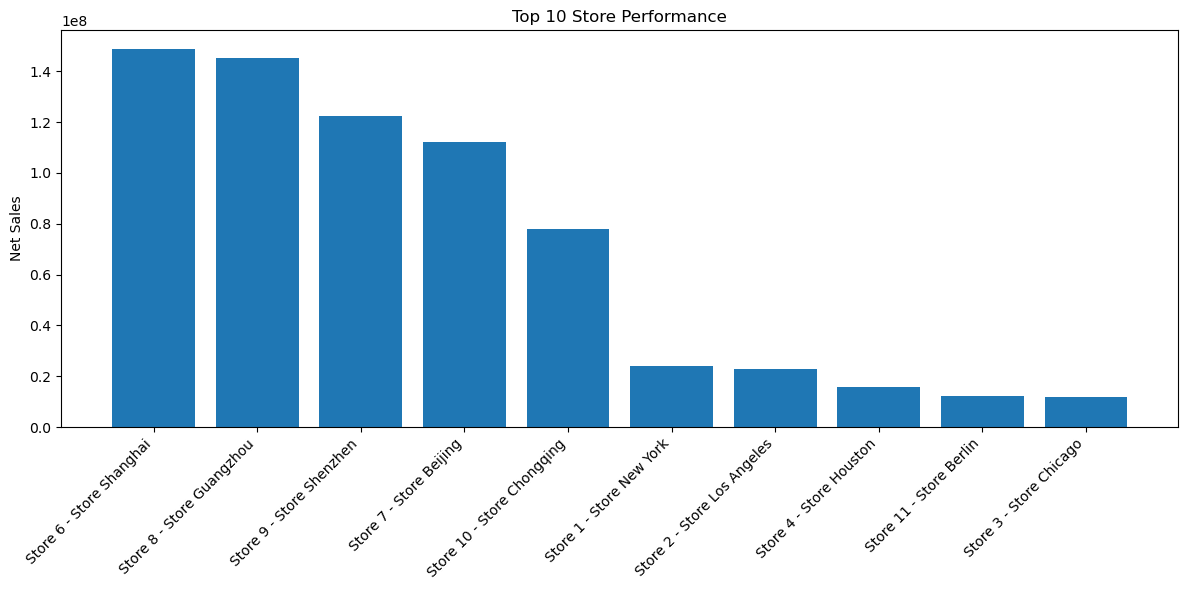

In [422]:
store_perf["Store Label"] = (
    "Store " + store_perf["Store ID"].astype(str)
    + " - " + store_perf["Store Name English"]
)

plt.figure(figsize=(12,6))
plt.bar(store_perf["Store Label"], store_perf["Net Sales"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Store Performance")
plt.ylabel("Net Sales")
plt.tight_layout()
plt.show()

## Customer / Geographic Analysis

This section evaluates revenue distribution across different countries to identify key markets.

**Observations:**
- China dominates total revenue by a large margin.
- The United States is a distant second, with significantly lower performance.
- European countries (UK, Spain, Portugal, France, Germany) contribute relatively small portions.

**Implications:**
- Revenue is highly concentrated in Asia, particularly China.
- Western markets show potential but are currently underperforming.

In [424]:
country_name_map = {
    "中国": "China",
    "Deutschland": "Germany",
    "España": "Spain",
    "United States": "United States",
    "United Kingdom": "United Kingdom",
    "Portugal": "Portugal",
    "France": "France",
    "Italy": "Italy"
}

clean_df["Customer Country Display"] = clean_df["Customer Country"].replace(country_name_map)

## Visualization

Bar chart of Net Sales by Customer Country

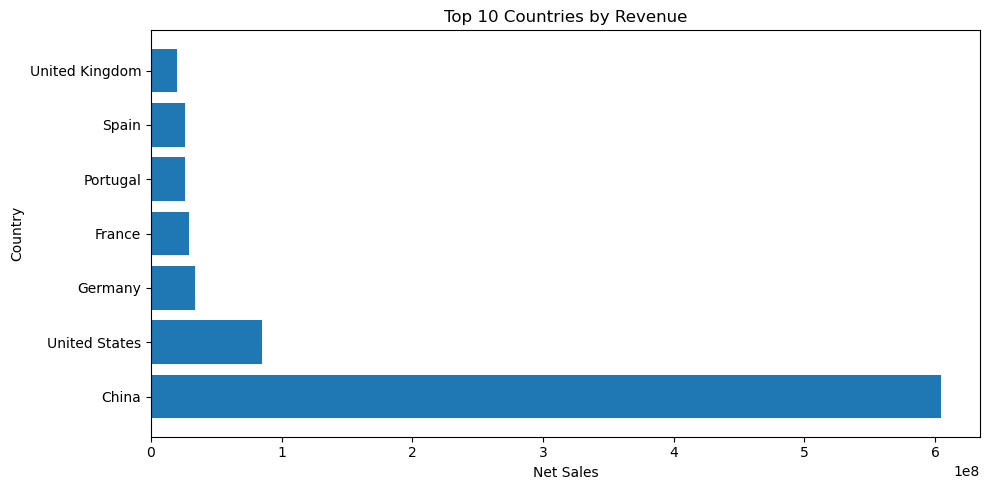

In [426]:
customer_perf = (
    clean_df.groupby("Customer Country Display")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_top = customer_perf.head(10)

plt.figure(figsize=(10,5))
plt.barh(customer_top["Customer Country Display"], customer_top["Net Sales"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Net Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Category Performance

This section analyzes which product categories contribute most to revenue.

**Observations:**
- Feminine and Masculine categories generate the majority of revenue.
- The Children category contributes significantly less.

**Implications:**
- Revenue is driven by a narrow set of categories.
- There is potential to grow underperforming categories.

In [428]:
category_perf = (
    clean_df.groupby("Category")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(category_perf)

    Category     Net Sales
0   Feminine  3.838272e+08
1  Masculine  3.681028e+08
2   Children  7.356657e+07


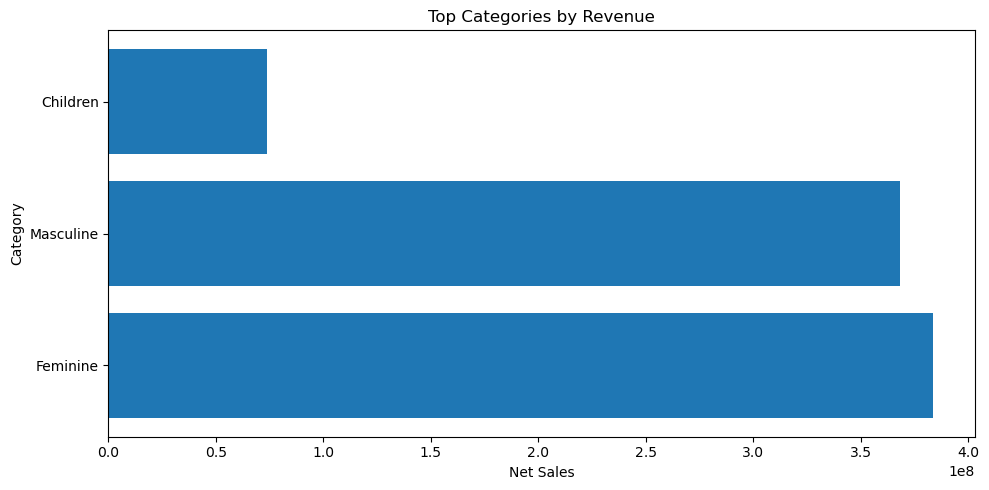

In [429]:
plt.figure(figsize=(10,5))
plt.barh(category_perf_sorted["Category"], category_perf_sorted["Net Sales"])
plt.title("Top Categories by Revenue")
plt.xlabel("Net Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Discount Impact Analysis

This section evaluates how discount rates affect transactions, revenue, and average sale value.

**Observations:**
- The highest number of transactions occurs at 0% discount.
- Higher discount levels are used less frequently.
- Revenue is heavily concentrated at low or no discount levels.
- Average net sales decrease as discount rates increase.

**Implications:**
- Discounts are not the primary driver of transaction volume.
- High discounts may reduce revenue quality and profitability.
- Strategic, moderate discounting is preferable to aggressive discounting.

**Visualizations:**
- Transactions vs Discount Rate (line chart)
- Revenue by Discount Rate (bar chart)
- Average Net Sale by Discount Rate (line chart)

In [431]:
discount_perf = (
    clean_df.groupby("Discount")["Net Sales"]
    .agg(["sum", "count"])
    .reset_index()
)

In [432]:
discount_perf.columns = ["Discount Rate", "Revenue", "Transactions"]

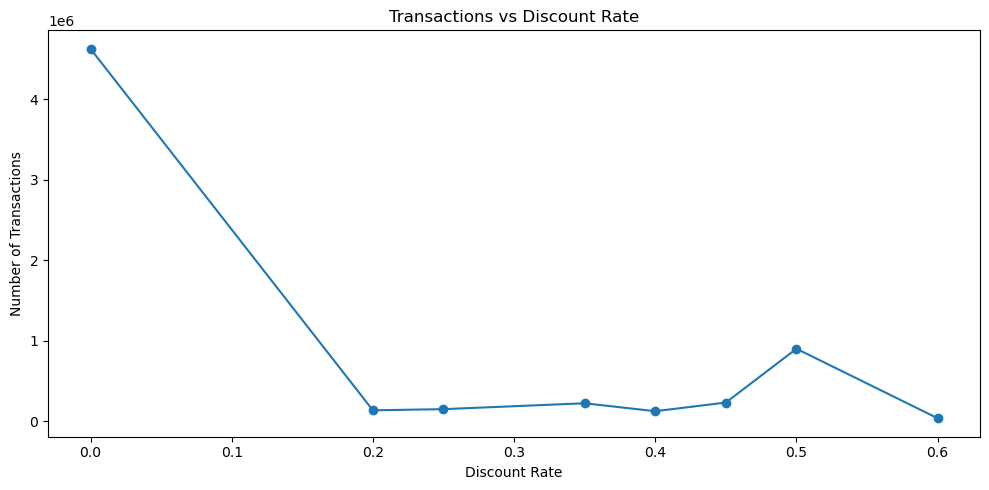

In [433]:
plt.figure(figsize=(10,5))
plt.plot(discount_perf["Discount Rate"], discount_perf["Transactions"], marker="o")
plt.title("Transactions vs Discount Rate")
plt.xlabel("Discount Rate")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [434]:
discount_perf = (
    clean_df.groupby("Discount")
    .agg(
        Revenue=("Net Sales", "sum"),
        Transactions=("Invoice ID", "nunique"),
        Average_Net_Sale=("Net Sales", "mean")
    )
    .reset_index()
    .rename(columns={"Discount": "Discount Rate"})
)

discount_perf

,Discount Rate,Revenue,Transactions,Average_Net_Sale
0,0.00,6.813415e+08,3339409,147.222822
1,0.20,1.566126e+07,106123,117.288227
2,0.25,1.370412e+07,116693,92.631096
3,0.35,1.823047e+07,177288,82.497909
4,0.40,8.550489e+06,97794,69.815295
5,0.45,1.812502e+07,182278,78.780439
6,0.50,6.769851e+07,642279,75.300465
7,0.60,2.185254e+06,24957,62.747775


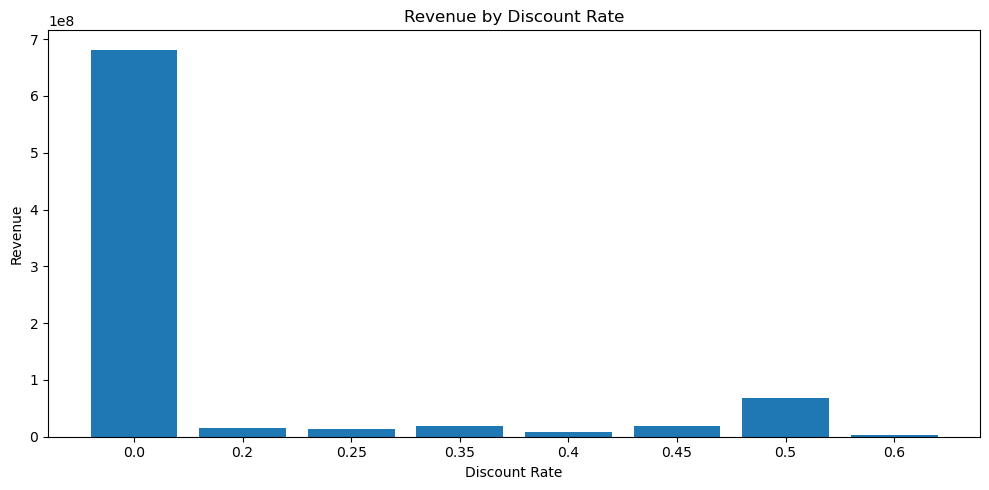

In [435]:
plt.figure(figsize=(10,5))
plt.bar(discount_perf["Discount Rate"].astype(str), discount_perf["Revenue"])
plt.title("Revenue by Discount Rate")
plt.xlabel("Discount Rate")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

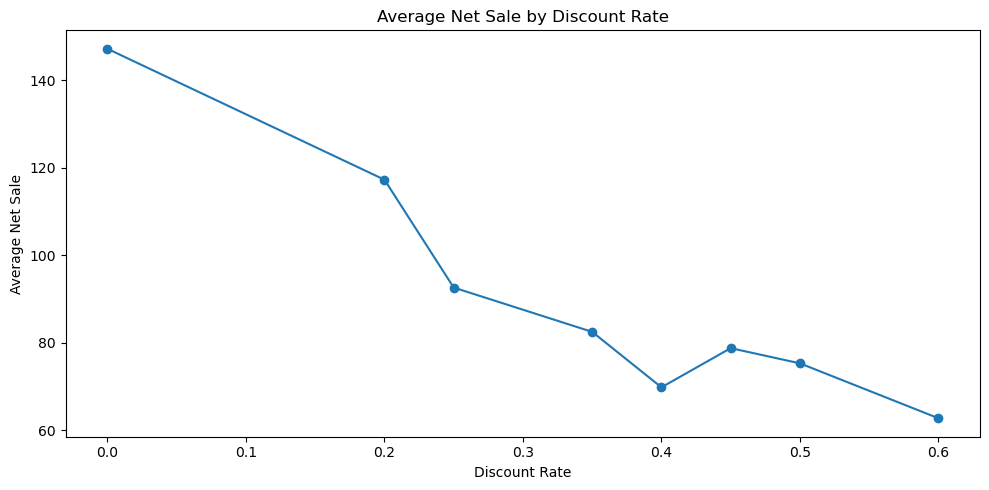

In [436]:
plt.figure(figsize=(10,5))
plt.plot(discount_perf["Discount Rate"], discount_perf["Average_Net_Sale"], marker="o")
plt.title("Average Net Sale by Discount Rate")
plt.xlabel("Discount Rate")
plt.ylabel("Average Net Sale")
plt.tight_layout()
plt.show()

## Payment Method Analysis

This section examines revenue distribution by payment method.

**Observations:**
- Credit card payments dominate total revenue.
- Cash contributes a significantly smaller share.

**Implications:**
- Customers strongly prefer digital payment methods.
- Optimizing the credit card checkout experience is critical.

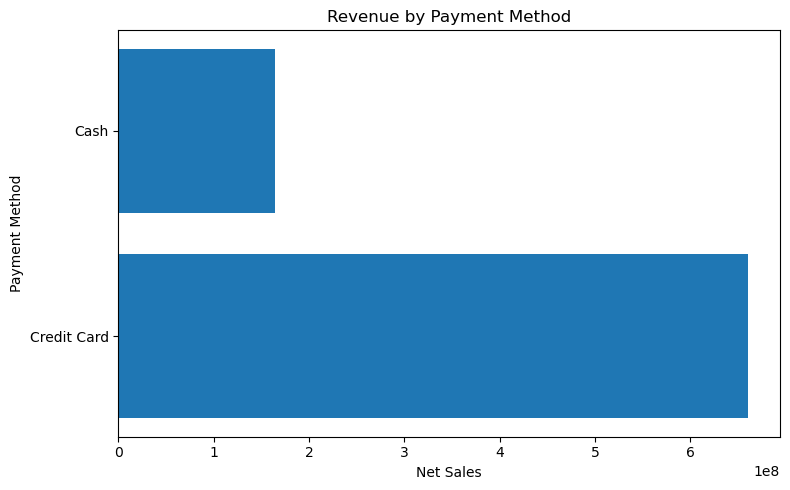

In [438]:
payment_perf = (
    clean_df.groupby("Payment Method")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_sorted = payment_perf.sort_values(by="Net Sales", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(payment_sorted["Payment Method"], payment_sorted["Net Sales"])
plt.title("Revenue by Payment Method")
plt.xlabel("Net Sales")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

## Key Insights

1. Revenue is highly concentrated geographically, with China significantly outperforming all other countries.
2. A small number of product categories (Feminine and Masculine) drive the majority of total revenue.
3. Most transactions occur at 0% discount, indicating that full-price sales dominate overall activity.
4. Higher discount rates are used less frequently and are associated with lower average net sales, suggesting diminishing returns from aggressive discounting.
5. Credit card payments account for the majority of revenue, indicating strong customer preference for non-cash transactions.
6. Revenue performance is uneven across markets, with Western markets contributing significantly less compared to Asian markets.

## Recommendations

1. Focus expansion and investment on high-performing markets like China while developing targeted strategies to improve performance in underperforming regions.

2. Prioritize top-performing categories (Feminine and Masculine) through inventory optimization, marketing campaigns, and product expansion.

3. Reevaluate discount strategy:
   - Avoid excessive high discount rates
   - Focus on targeted, moderate discounts that maintain margins
   - Test whether discounts actually increase transaction volume

4. Leverage dominant payment methods:
   - Optimize checkout experience for credit card users
   - Minimize payment failures and processing delays

5. Explore growth opportunities in lower-performing countries by:
   - Adjusting pricing strategies
   - Localizing product offerings
   - Increasing marketing efforts

6. Monitor average net sales closely when applying discounts to ensure profitability is not being eroded.

---

## Conclusion
This analysis highlights the importance of geographic focus, category prioritization, and disciplined pricing strategies in driving retail performance.


## Author
Oreoluwa Kushimo